In [1]:
import pandas as pd
import numpy as np

In [3]:
movies = pd.read_csv('movies.csv')

In [4]:
ipl_matches = pd.read_csv('ipl-matches.csv')

In [8]:
#1 Find all the final Winners

ipl_matches.shape

(950, 20)

In [23]:
ipl_matches[['WinningTeam','Season']][ipl_matches['MatchNumber'] == 'Final']

,WinningTeam,Season
0,Gujarat Titans,2022
74,Chennai Super Kings,2021
134,Mumbai Indians,2020/21
194,Mumbai Indians,2019
254,Chennai Super Kings,2018
314,Mumbai Indians,2017
373,Sunrisers Hyderabad,2016
433,Mumbai Indians,2015
492,Kolkata Knight Riders,2014
552,Mumbai Indians,2013


In [18]:
#How many super over finishes have occured 

superover_count = ipl_matches['SuperOver'].value_counts()

print(f"Total SuperOver count is {superover_count[1]}")

Total SuperOver count is 14


C:\Users\RonitJadhav\AppData\Local\Temp\ipykernel_23228\4170064942.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Total SuperOver count is {superover_count[1]}")


In [38]:
# How many Matches CSK has won in Kolkata 
ipl_matches[ipl_matches['City'].str.contains('Kolkata') & ipl_matches['WinningTeam'].str.contains('Chennai Super Kings')].shape[0]



5

In [33]:
ipl_matches.head()

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough
3,1312197,Kolkata,2022-05-24,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,N,Gujarat Titans,Wickets,7.0,NaN,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma
4,1304116,Mumbai,2022-05-22,2022,70,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,N,Punjab Kings,Wickets,5.0,NaN,Harpreet Brar,"['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...","['JM Bairstow', 'S Dhawan', 'M Shahrukh Khan',...",AK Chaudhary,NA Patwardhan


In [65]:
# Toss Winner is match Winner in the Percentage

(ipl_matches[ipl_matches['TossWinner'] == ipl_matches['WinningTeam']].shape[0]/ipl_matches.shape[0])*100

51.473684210526315

In [44]:
# Movies with rating higher than 8 and votes > 10000

movies.columns

Index(['title_x', 'imdb_id', 'poster_path', 'wiki_link', 'title_y',
       'original_title', 'is_adult', 'year_of_release', 'runtime', 'genres',
       'imdb_rating', 'imdb_votes', 'story', 'summary', 'tagline', 'actors',
       'wins_nominations', 'release_date'],
      dtype='object')

In [55]:
movies[(movies['imdb_rating'] > 8) & (movies['imdb_votes'] > 10000)].shape[0]

43

In [59]:
movies[(movies['genres'].str.contains('Action')) & (movies['imdb_rating'] > 7.5)].shape[0]

33

In [76]:
# Find Which Player has won the most potm -> in the finals and qualifiers

players_list = ipl_matches['Player_of_Match'][ipl_matches['MatchNumber'].str.contains('Final','Qualifiers')]

players_list.value_counts().head(5)

Player_of_Match
KA Pollard    2
SR Watson     2
MK Pandey     2
MS Dhoni      1
YK Pathan     1
Name: count, dtype: int64

In [79]:
ipl_matches[~ipl_matches['MatchNumber'].str.isdigit()]['Player_of_Match'].value_counts().head(5)

Player_of_Match
KA Pollard      3
F du Plessis    3
SK Raina        3
A Kumble        2
MK Pandey       2
Name: count, dtype: int64

In [81]:
ipl_matches['TossDecision'].value_counts()

TossDecision
field    599
bat      351
Name: count, dtype: int64

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt

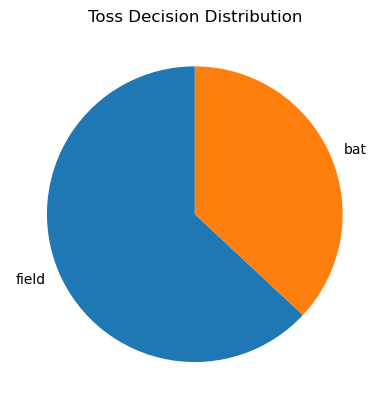

In [89]:
plt.pie(ipl_matches['TossDecision'].value_counts(),labels=ipl_matches['TossDecision'].value_counts().index,startangle=90)
plt.title('Toss Decision Distribution')

plt.show()

In [100]:
# How Many Matches Each Team has Played

(ipl_matches['Team1'].value_counts() + ipl_matches['Team2'].value_counts()).sort_values(ascending=False)

Mumbai Indians                 231
Royal Challengers Bangalore    226
Kolkata Knight Riders          223
Chennai Super Kings            208
Rajasthan Royals               192
Kings XI Punjab                190
Delhi Daredevils               161
Sunrisers Hyderabad            152
Deccan Chargers                 75
Delhi Capitals                  63
Pune Warriors                   46
Gujarat Lions                   30
Punjab Kings                    28
Gujarat Titans                  16
Rising Pune Supergiant          16
Lucknow Super Giants            15
Kochi Tuskers Kerala            14
Rising Pune Supergiants         14
Name: count, dtype: int64